In [1]:
!pip install yfinance
import yfinance as yf
import numpy as np

stock=yf.download("META", period="1y")
close=stock["Close"].squeeze()

S=close.iloc[-1]
daily_returns=close.pct_change()
sigma=daily_returns.std()*np.sqrt(252)

print("Current Stock Price", S)
print("Annualized Volatility", sigma)

/tmp/ipykernel_4570/714944164.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock=yf.download("META", period="1y")
[*********************100%***********************]  1 of 1 completed

Current Stock Price 556.7100219726562
Annualized Volatility 0.38161942937420285


In [2]:
K=560
T=30/365
r=0.05

In [3]:
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
  d1=(np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
  d2=d1-sigma*np.sqrt(T)
  price=S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
  return price

call_price=black_scholes_call(S, K, T, r, sigma)
print(call_price)

23.814853473181813


In [4]:
def black_scholes_delta(S, K, T, r, sigma):
  d1=(np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
  delta=norm.cdf(d1)
  return delta

delta=black_scholes_delta(S, K, T, r, sigma)
print(delta)

0.5153193070215827


In [5]:
def black_scholes_gamma(S, K, T, r ,sigma):
  d1=(np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
  gamma=norm.pdf(d1)/(S*sigma*np.sqrt(T))
  return gamma

gamma=black_scholes_gamma(S, K, T, r, sigma)
print(gamma)

0.006545095719960217


In [6]:
def black_scholes_vega(S, K, T, r, sigma):
  d1=(np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
  vega=S*norm.pdf(d1)*np.sqrt(T)
  return vega/100

vega=black_scholes_vega(S, K, T, r, sigma)
print(vega)

0.6362575511954073


In [7]:
def black_scholes_theta(S, K, T, r, sigma):
  d1=(np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
  d2=d1-sigma*np.sqrt(T)
  theta=(-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)))-r*K*np.exp(-r*T)*norm.cdf(d2)
  return theta/365

theta=black_scholes_theta(S, K, T, r, sigma)
print(theta)

-0.4407171963468587


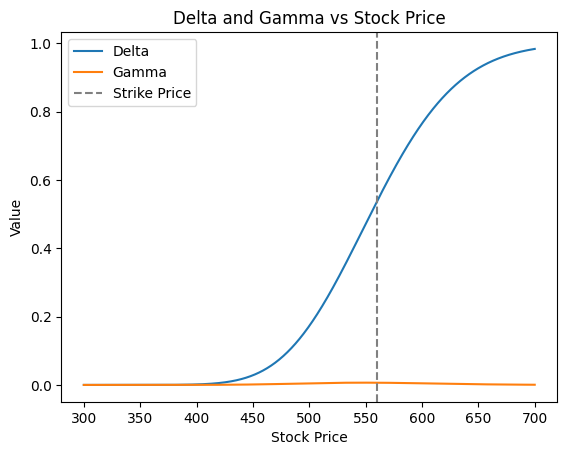

In [12]:
import matplotlib.pyplot as plt

stock_prices=np.linspace(300, 700, 1000)
deltas=[black_scholes_delta(s, K, T, r, sigma) for s in stock_prices]
gammas=[black_scholes_gamma(s, K, T, r, sigma) for s in stock_prices]

plt.plot(stock_prices, deltas, label="Delta")
plt.plot(stock_prices, gammas, label="Gamma")
plt.axvline(x=K, color="grey", linestyle="--", label="Strike Price")
plt.title("Delta and Gamma vs Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Value")
plt.legend()
plt.savefig("greeks_chart_META.png")
plt.show()

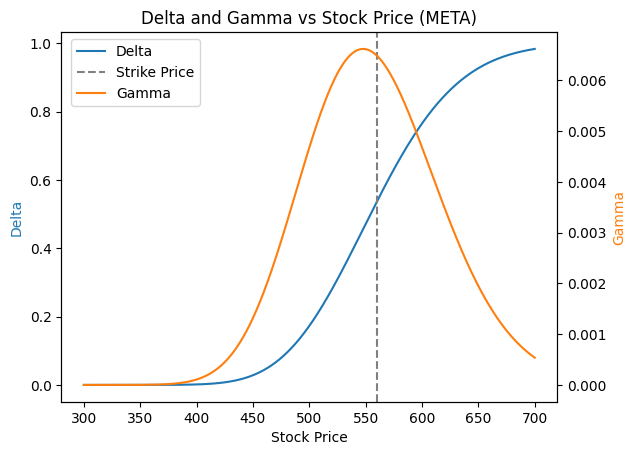

In [13]:
fig, ax1 = plt.subplots()

ax1.plot(stock_prices, deltas, label="Delta", color="tab:blue")
ax1.set_xlabel("Stock Price")
ax1.set_ylabel("Delta", color="tab:blue")
ax1.axvline(x=K, color="grey", linestyle="--", label="Strike Price")

ax2 = ax1.twinx()
ax2.plot(stock_prices, gammas, label="Gamma", color="tab:orange")
ax2.set_ylabel("Gamma", color="tab:orange")

plt.title("Delta and Gamma vs Stock Price (META)")
fig.legend(loc="upper left", bbox_to_anchor=(0.13, 0.88))
plt.savefig("greeks_chart_META.png")
plt.show()